In [5]:
import pandas as pd

In [6]:
from sklearn.datasets import fetch_california_housing

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = fetch_california_housing()

In [9]:
dataset = pd.DataFrame(df.data)

In [10]:
dataset.columns = df.feature_names

In [11]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [12]:
# independent and dependent features

In [13]:
X = dataset
y = df.target

In [14]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [15]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [16]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.30, random_state = 42)

In [17]:
# statndardisation process

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [19]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
X_train

array([[ 0.13350629,  0.50935748,  0.18106017, ..., -0.01082519,
        -0.80568191,  0.78093406],
       [-0.53221805, -0.67987313, -0.42262953, ..., -0.08931585,
        -1.33947268,  1.24526986],
       [ 0.1709897 , -0.36274497,  0.07312833, ..., -0.04480037,
        -0.49664515, -0.27755183],
       ...,
       [-0.49478713,  0.58863952, -0.59156984, ...,  0.01720102,
        -0.75885816,  0.60119118],
       [ 0.96717102, -1.07628333,  0.39014889, ...,  0.00482125,
         0.90338501, -1.18625198],
       [-0.68320166,  1.85715216, -0.82965604, ..., -0.0816717 ,
         0.99235014, -1.41592345]])

In [21]:
X_test

array([[-1.1526893 , -0.28346293, -0.50781822, ...,  0.06127763,
         0.19166399,  0.28664112],
       [-0.70640568,  0.11294728, -0.16252032, ..., -0.03551561,
        -0.23911452,  0.06196251],
       [-0.20830675,  1.85715216, -0.59546738, ..., -0.14215427,
         1.00639726, -1.42590916],
       ...,
       [-0.19155996, -0.99700129, -0.6830438 , ..., -0.06058827,
        -0.92742367,  0.8358555 ],
       [-0.11911302, -1.47269353,  0.02607207, ...,  0.03461374,
         1.01576201, -0.84673764],
       [-0.43304974, -0.91771925, -0.84872893, ..., -0.0407528 ,
        -0.70266966,  0.67109119]])

In [22]:
scaler.inverse_transform(X_train)

array([[   4.1312    ,   35.        ,    5.88235294, ...,    2.98529412,
          33.93      , -118.02      ],
       [   2.8631    ,   20.        ,    4.40120968, ...,    2.0141129 ,
          32.79      , -117.09      ],
       [   4.2026    ,   24.        ,    5.61754386, ...,    2.56491228,
          34.59      , -120.14      ],
       ...,
       [   2.9344    ,   36.        ,    3.98671727, ...,    3.33206831,
          34.03      , -118.38      ],
       [   5.7192    ,   15.        ,    6.39534884, ...,    3.17889088,
          37.58      , -121.96      ],
       [   2.5755    ,   52.        ,    3.40257649, ...,    2.10869565,
          37.77      , -122.42      ]])

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [24]:
regression = LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [25]:
mse = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv = 5)

In [26]:
np.mean(mse)

np.float64(-0.5268253746355748)

In [27]:
# prediction

In [28]:
reg_pred = regression.predict(X_test)

In [29]:
reg_pred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133])

In [30]:
# visualisation

In [31]:
import seaborn as sns

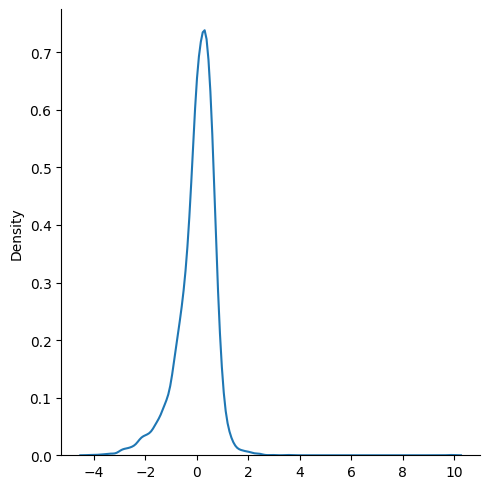

In [32]:
sns.displot(reg_pred - y_test,kind = "kde")

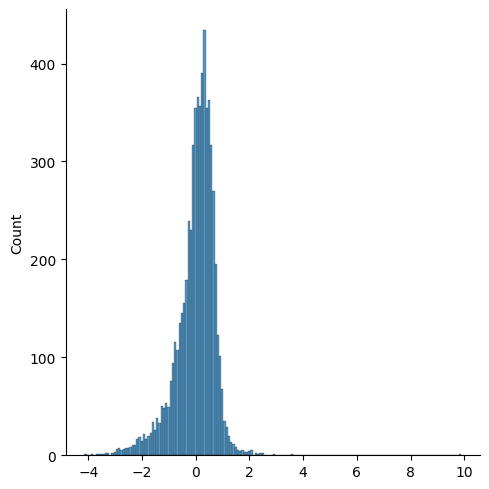

In [33]:
sns.displot(reg_pred-y_test)

In [34]:
from sklearn.metrics import r2_score

In [35]:
score = r2_score(reg_pred,y_test)

In [36]:
score

0.3451339380943985

In [37]:
# ridge regression

In [38]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [39]:
ridge_regressor = Ridge()

In [40]:
ridge_regressor

Ridge()

In [43]:
parameters = {'alpha' : [1,2,3,4,5,6,7,8,9,10.20,30,40,50,60,70,80,90,100]}
ridgecv = GridSearchCV(ridge_regressor,parameters,scoring='neg_mean_squared_error',cv=5)
ridgecv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10.2, 30, 40, 50,
                                   60, 70, 80, 90, 100]},
             scoring='neg_mean_squared_error')

In [44]:
print(ridgecv.best_params_)

{'alpha': 7}


In [ ]:
# use alpha = 7

In [45]:
print(ridgecv.best_score_)

-0.526817617099752


In [46]:
ridgepredict = ridgecv.predict(X_test)

In [47]:
ridgepredict

array([0.72876749, 1.76609082, 2.70809002, ..., 2.07324134, 1.57484847,
       1.8263492 ])

In [ ]:
# visualisation using seaborn

In [48]:
import seaborn as sns

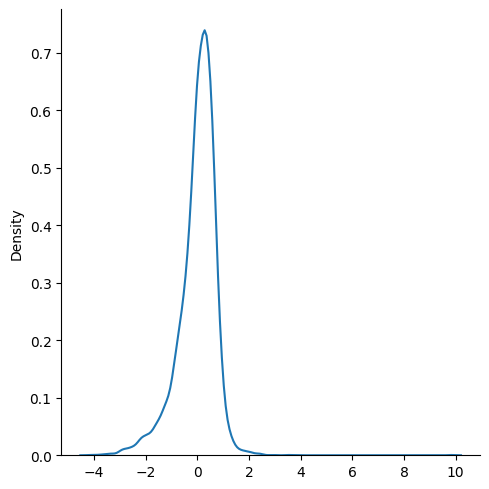

In [50]:
sns.displot(ridgepredict - y_test,kind = "kde")

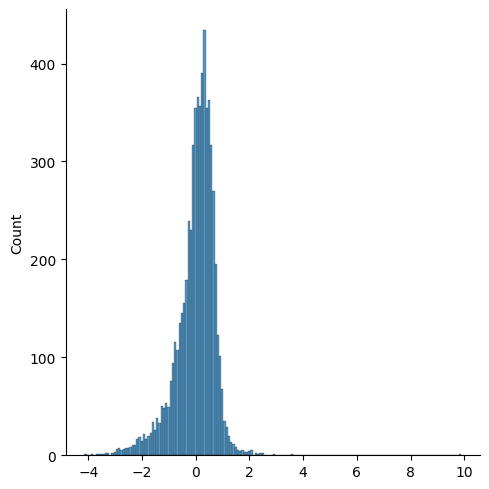

In [51]:
sns.displot(reg_pred-y_test)

In [52]:
from sklearn.metrics import r2_score

In [53]:
score = r2_score(ridgepredict,y_test)

In [54]:
score

0.3433218965947866

In [ ]:
# lasso regression

In [55]:
from sklearn.linear_model import Lasso

In [56]:
lasso = Lasso()

In [58]:
parameters = {'alpha' : [1,2,3,4,5,6,7,8,9,10.20,30,40,50,60,70,80,90,100]}
lassocv = GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)
lassocv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10.2, 30, 40, 50,
                                   60, 70, 80, 90, 100]},
             scoring='neg_mean_squared_error')

In [60]:
print(lassocv.best_params_)
print(lassocv.best_score_)

{'alpha': 1}
-1.3400019579636542


In [61]:
lassopredict = lassocv.predict(X_test)

In [62]:
lassopredict

array([2.06923961, 2.06923961, 2.06923961, ..., 2.06923961, 2.06923961,
       2.06923961])

In [ ]:
# visualisation using seaborn

In [63]:
import seaborn as sns

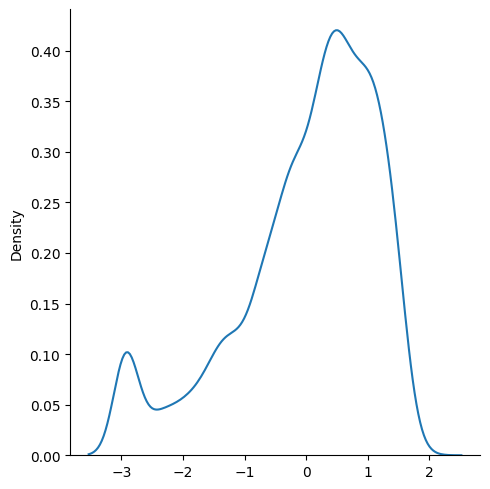

In [66]:
sns.displot(lassopredict - y_test,kind = "kde")

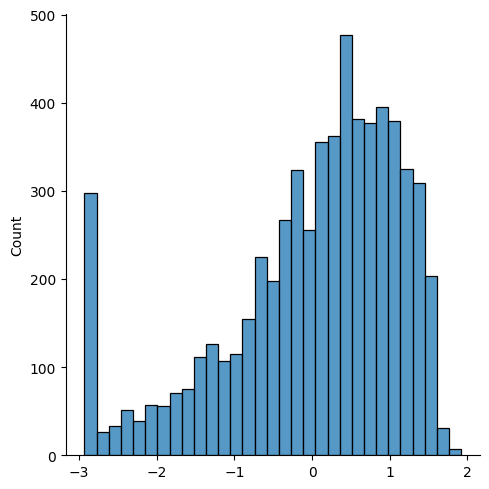

In [68]:
sns.displot(lassopredict-y_test)

In [ ]:
# finding r2_square

In [69]:
from sklearn.metrics import r2_score

In [70]:
score = r2_score(ridgepredict,y_test)

In [71]:
score

0.3433218965947866